# Semi-supervised Classification on a Text Dataset

https://scikit-learn.org/stable/auto_examples/semi_supervised/plot_semi_supervised_newsgroups.html

In [1]:
from sklearn.datasets import fetch_20newsgroups
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import f1_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.semi_supervised import LabelPropagation, LabelSpreading, SelfTrainingClassifier

In [2]:
# Loading dataset containing first five categories
data = fetch_20newsgroups(
    subset="train",
    categories=[
        "alt.atheism",
        "comp.graphics",
        "comp.os.ms-windows.misc",
        "comp.sys.ibm.pc.hardware",
        "comp.sys.mac.hardware",
    ],
)

print(data.keys())
print()
print(len(data['data']))
print(len(data['target']))
print()

sample = 1
print(data['data'][sample])
print(data['target'][sample])

dict_keys(['data', 'filenames', 'target_names', 'target', 'DESCR'])

2823
2823

From: gtonwu@Uz.nthu.edu.tw (Tony G. Wu)
Subject: Is it possible ?
Organization: National Tsing Hua University (HsinChu)
X-Newsreader: TIN [version 1.1 PL8]
Lines: 13


Hello.

      Is it possible to know minimize program manager when starting an
      application and to restore it when the application is ended ?
      If possible, please tell me how to do it !


-- 
===================== ( Forever  23,  Michael Jordan.) =====================
    Tony G. Wu                                     gtonwu@uz.nthu.edu.tw 
    CAE/Rheology Lab.  NTHU.                       tony@che.nthu.edu.tw
   

2


In [3]:
# Parameters
sdg_params = {"alpha": 1e-5, "penalty": "l2", "loss": "log_loss"}
vectorizer_params = {"ngram_range": (1, 2), "min_df": 5, "max_df": 0.8}

# Supervised Pipeline
pipeline = Pipeline(
    [
        ("vect", CountVectorizer(**vectorizer_params)),
        ("tfidf", TfidfTransformer()),
        ("clf", SGDClassifier(**sdg_params)),
    ]
)
# SelfTraining Pipeline
st_pipeline = Pipeline(
    [
        ("vect", CountVectorizer(**vectorizer_params)),
        ("tfidf", TfidfTransformer()),
        ("clf", SelfTrainingClassifier(SGDClassifier(**sdg_params))),
    ]
)
# LabelSpreading Pipeline
ls_pipeline = Pipeline(
    [
        ("vect", CountVectorizer(**vectorizer_params)),
        ("tfidf", TfidfTransformer()),
        ("clf", LabelSpreading()),
    ]
)
# LabelSpreading with a kNN graph instead of the default RBF kernel
ls_knn_pipeline = Pipeline(
    [
        ("vect", CountVectorizer(**vectorizer_params)),
        ("tfidf", TfidfTransformer()),
        ("clf", LabelSpreading(kernel="knn", n_neighbors=10, alpha=0.2, max_iter=100)),
    ]
)

In [4]:
X, y = data['data'], data['target']
X_train, X_test, y_train, y_test = train_test_split(X, y)

len(X_train), len(y_train)

(2117, 2117)

In [5]:
def eval_and_get_f1(clf, X_train, y_train, X_test, y_test):
    """Evaluate model performance and return F1 score"""
    print(f"   Number of training samples: {len(X_train)}")
    print(f"   Unlabeled samples in training set: {sum(1 for x in y_train if x == -1)}")
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    f1 = f1_score(y_test, y_pred, average="micro")
    print(f"   Micro-averaged F1 score on test set: {f1:.3f}")
    print("\n")
    return f1

In [6]:
# Evaluate a supervised SGDClassifier using 100% of the (labeled) training set
f1_scores = {}
print("1. Supervised SGDClassifier on 100% of the data:")
f1_scores["Supervised (100%)"] = eval_and_get_f1(
    pipeline, X_train, y_train, X_test, y_test
)

1. Supervised SGDClassifier on 100% of the data:
   Number of training samples: 2117
   Unlabeled samples in training set: 0
   Micro-averaged F1 score on test set: 0.905




In [7]:
# Evaluate a supervised SGDClassifier trained on only 20% of the data
import numpy as np

print("2. Supervised SGDClassifier on 20% of the training data:")
rng = np.random.default_rng(42)
y_mask = rng.random(len(y_train)) < 0.2
# X_20 and y_20 are the subset of the train dataset indicated by the mask
X_20, y_20 = map(list, zip(*((x, y) for x, y, m in zip(X_train, y_train, y_mask) if m)))
f1_scores["Supervised (20%)"] = eval_and_get_f1(pipeline, X_20, y_20, X_test, y_test)

2. Supervised SGDClassifier on 20% of the training data:
   Number of training samples: 434
   Unlabeled samples in training set: 0
   Micro-averaged F1 score on test set: 0.773




In [8]:
# Evaluate a semi-supervised SelfTrainingClassifier using 20% labeled and 80% unlabeled data
print(
    "3. SelfTrainingClassifier (semi-supervised) using 20% labeled "
    "+ 80% unlabeled data):"
)
y_train_semi = y_train.copy()
y_train_semi[~y_mask] = -1
f1_scores["SelfTraining"] = eval_and_get_f1(
    st_pipeline, X_train, y_train_semi, X_test, y_test
)

3. SelfTrainingClassifier (semi-supervised) using 20% labeled + 80% unlabeled data):
   Number of training samples: 2117
   Unlabeled samples in training set: 1683
   Micro-averaged F1 score on test set: 0.817




In [9]:
# Evaluate a semi-supervised LabelSpreading model using 20% labeled and 80% unlabeled data
print("4. LabelSpreading (semi-supervised) using 20% labeled + 80% unlabeled data:")
f1_scores["LabelSpreading (rbf)"] = eval_and_get_f1(
    ls_pipeline, X_train, y_train_semi, X_test, y_test
)

4. LabelSpreading (semi-supervised) using 20% labeled + 80% unlabeled data:
   Number of training samples: 2117
   Unlabeled samples in training set: 1683
   Micro-averaged F1 score on test set: 0.644




In [10]:
print("5. LabelSpreading (kNN kernel) using 20% labeled + 80% unlabeled data:")
f1_scores["LabelSpreading (kNN)"] = eval_and_get_f1(
    ls_knn_pipeline, X_train, y_train_semi, X_test, y_test
)

5. LabelSpreading (kNN kernel) using 20% labeled + 80% unlabeled data:
   Number of training samples: 2117
   Unlabeled samples in training set: 1683
   Micro-averaged F1 score on test set: 0.644




In [11]:
# Use embedding instead of tfidf
from sentence_transformers import SentenceTransformer

emb_model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

E_train = emb_model.encode(X_train)
E_test = emb_model.encode(X_test)
E_20, y_20_arr = E_train[y_mask], y_train[y_mask]

print("Emb Supervised (100%):")
f1_scores["Emb Supervised (100%)"] = eval_and_get_f1(SGDClassifier(**sdg_params), E_train, y_train, E_test, y_test)

print("Emb Supervised (20%):")
f1_scores["Emb Supervised (20%)"] = eval_and_get_f1(SGDClassifier(**sdg_params), E_20, y_20_arr, E_test, y_test)

print("Emb SelfTraining:")
f1_scores["Emb SelfTraining"] = eval_and_get_f1(SelfTrainingClassifier(SGDClassifier(**sdg_params)), E_train, y_train_semi, E_test, y_test)

print("Emb LabelSpreading:")
f1_scores["Emb LabelSpreading"] = eval_and_get_f1(LabelSpreading(kernel="knn", n_neighbors=10, max_iter=100), E_train, y_train_semi, E_test, y_test)

print("Emb LabelPropagation:")
f1_scores["Emb LabelPropagation"] = eval_and_get_f1(LabelPropagation(kernel="knn", n_neighbors=10, max_iter=100), E_train, y_train_semi, E_test, y_test)


/Users/ryanroche/repositories/tamu/fall26-code/csce-685/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 24310.02it/s]


Emb Supervised (100%):
   Number of training samples: 2117
   Unlabeled samples in training set: 0
   Micro-averaged F1 score on test set: 0.846


Emb Supervised (20%):
   Number of training samples: 434
   Unlabeled samples in training set: 0
   Micro-averaged F1 score on test set: 0.796


Emb SelfTraining:
   Number of training samples: 2117
   Unlabeled samples in training set: 1683
   Micro-averaged F1 score on test set: 0.800


Emb LabelSpreading:
   Number of training samples: 2117
   Unlabeled samples in training set: 1683
   Micro-averaged F1 score on test set: 0.807


Emb LabelPropagation:
   Number of training samples: 2117
   Unlabeled samples in training set: 1683
   Micro-averaged F1 score on test set: 0.776




/Users/ryanroche/repositories/tamu/fall26-code/csce-685/.venv/lib/python3.12/site-packages/sklearn/semi_supervised/_label_propagation.py:325: ConvergenceWarning: max_iter=100 was reached without convergence.
  warnings.warn(


## Plot Results

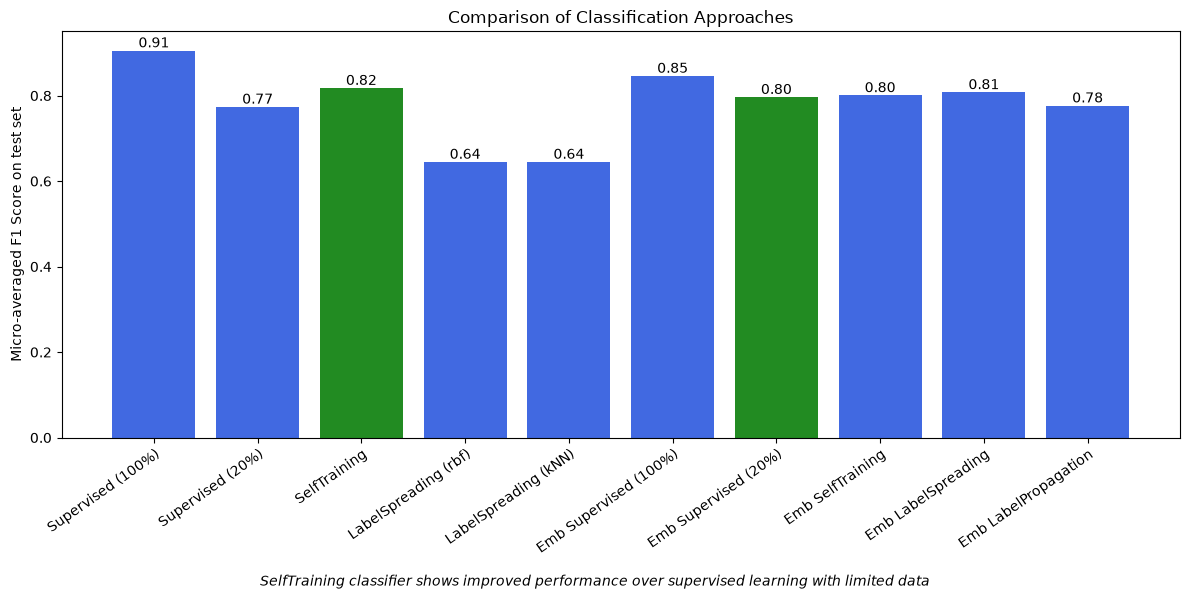

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

models = list(f1_scores.keys())
scores = list(f1_scores.values())

colors = ["royalblue", "royalblue", "forestgreen", "royalblue"]
bars = plt.bar(models, scores, color=colors)

plt.title("Comparison of Classification Approaches")
plt.ylabel("Micro-averaged F1 Score on test set")
plt.xticks(rotation=35, ha="right", rotation_mode="anchor")

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2.0,
        height,
        f"{height:.2f}",
        ha="center",
        va="bottom",
    )

plt.figtext(
    0.5,
    0.01,
    "SelfTraining classifier shows improved performance over "
    "supervised learning with limited data",
    ha="center",
    va="bottom",
    fontsize=10,
    style="italic",
)

# Leave room at the bottom for the caption; tight_layout fits the rotated labels above it
plt.tight_layout(rect=(0, 0.04, 1, 1))
plt.show()